In [8]:
# Load the USArrests dataset
data("USArrests")

# View the first few rows of the dataset
head(USArrests)


,Murder,Assault,UrbanPop,Rape
,<dbl>,<int>,<int>,<dbl>
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7


In [9]:
library(tidyverse)

     Murder          Assault         UrbanPop          Rape      
 Min.   : 0.800   Min.   : 45.0   Min.   :32.00   Min.   : 7.30  
 1st Qu.: 4.075   1st Qu.:109.0   1st Qu.:54.50   1st Qu.:15.07  
 Median : 7.250   Median :159.0   Median :66.00   Median :20.10  
 Mean   : 7.788   Mean   :170.8   Mean   :65.54   Mean   :21.23  
 3rd Qu.:11.250   3rd Qu.:249.0   3rd Qu.:77.75   3rd Qu.:26.18  
 Max.   :17.400   Max.   :337.0   Max.   :91.00   Max.   :46.00  

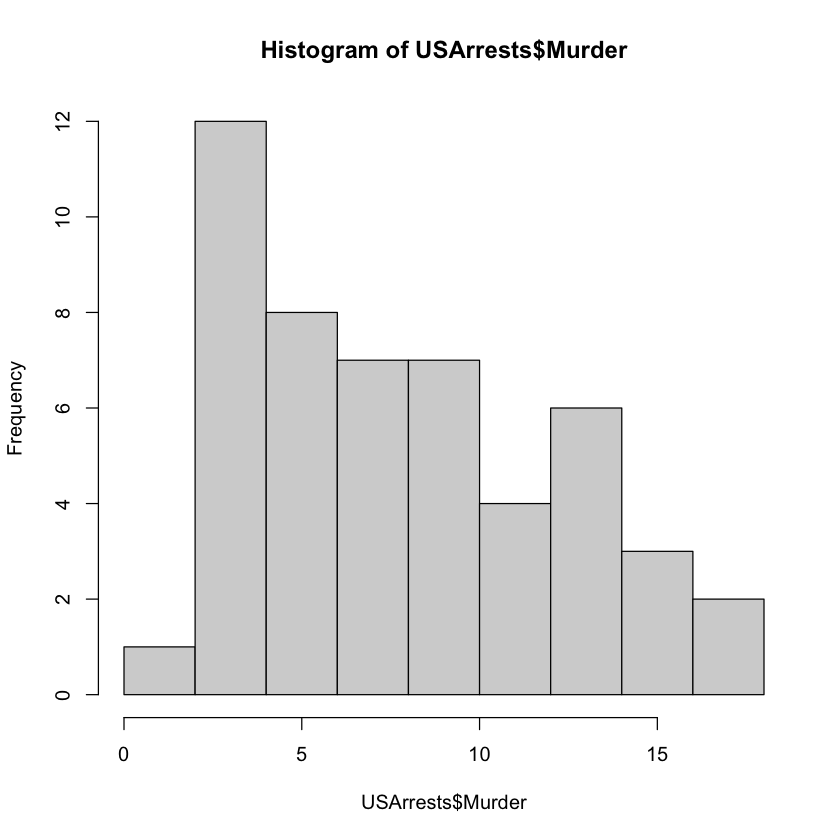

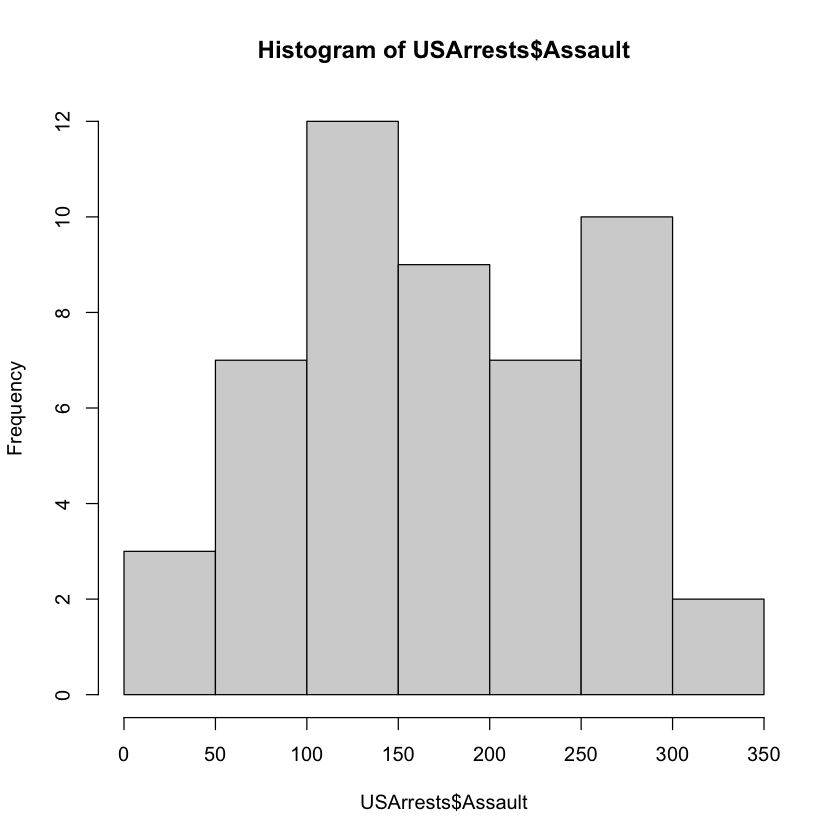

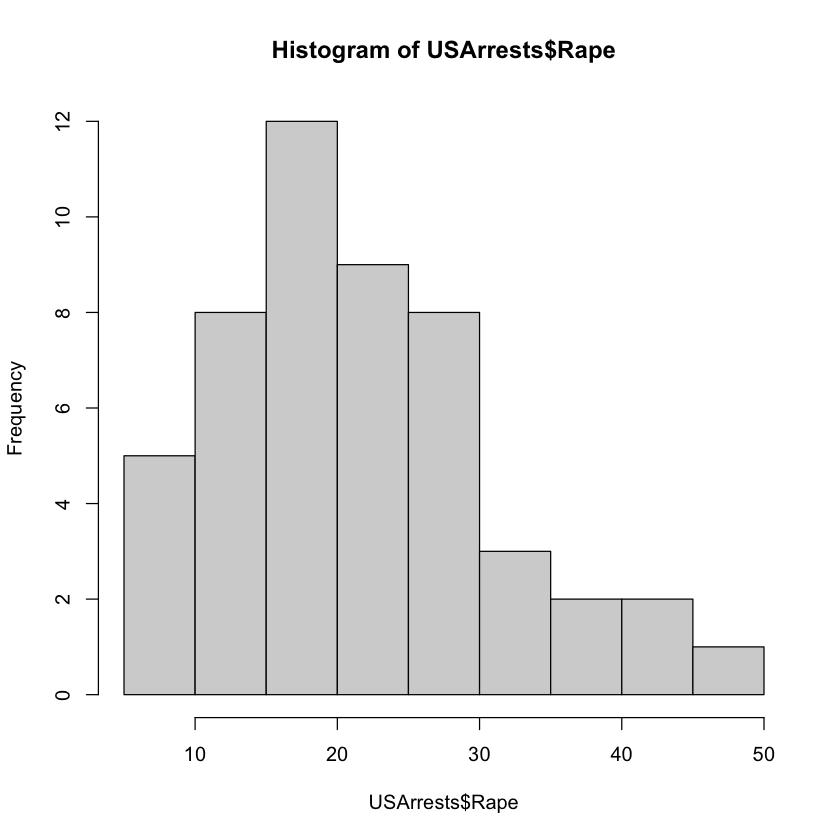

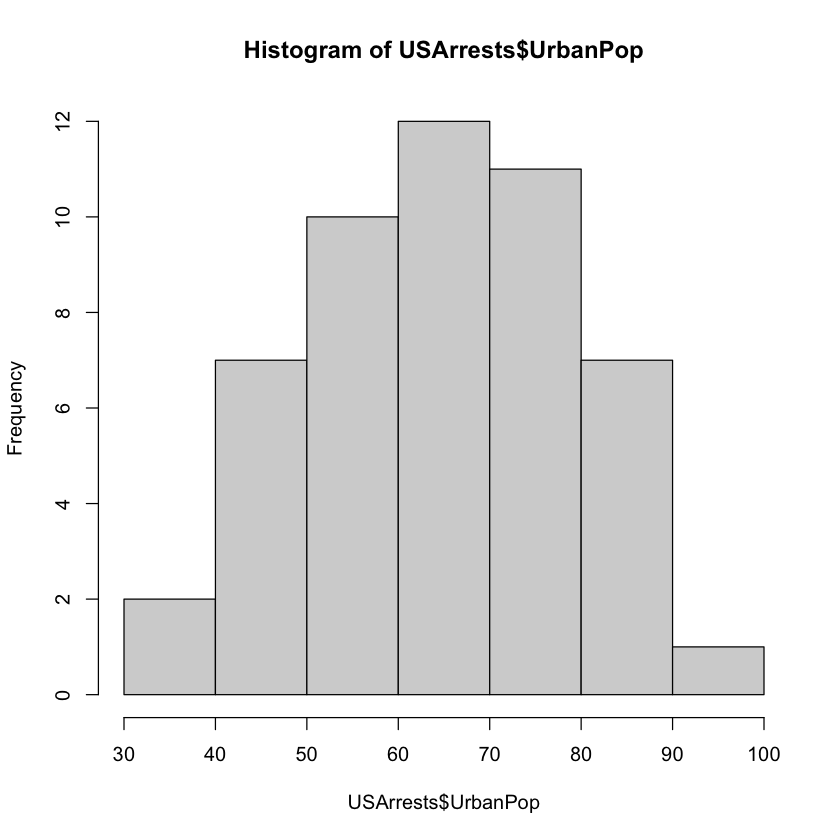

In [10]:
summary(USArrests)
hist(USArrests$Murder)
hist(USArrests$Assault)
hist(USArrests$Rape)
hist(USArrests$UrbanPop)
arrest.scal=scale(USArrests)

In [11]:
clus2=kmeans(arrest.scal,centers=2,nstart = 25)
clus2

K-means clustering with 2 clusters of sizes 30, 20

Cluster means:
     Murder    Assault   UrbanPop       Rape
1 -0.669956 -0.6758849 -0.1317235 -0.5646433
2  1.004934  1.0138274  0.1975853  0.8469650

Clustering vector:
       Alabama         Alaska        Arizona       Arkansas     California 
             2              2              2              1              2 
      Colorado    Connecticut       Delaware        Florida        Georgia 
             2              1              1              2              2 
        Hawaii          Idaho       Illinois        Indiana           Iowa 
             1              1              2              1              1 
        Kansas       Kentucky      Louisiana          Maine       Maryland 
             1              1              2              1              2 
 Massachusetts       Michigan      Minnesota    Mississippi       Missouri 
             1              2              1              2              2 
       Montana    

In [15]:
install.packages("factoextra")
library(factoextra)

also installing the dependencies 'estimability', 'emmeans', 'flashClust', 'dendextend', 'FactoMineR'





The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpJly9ML/downloaded_packages


Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



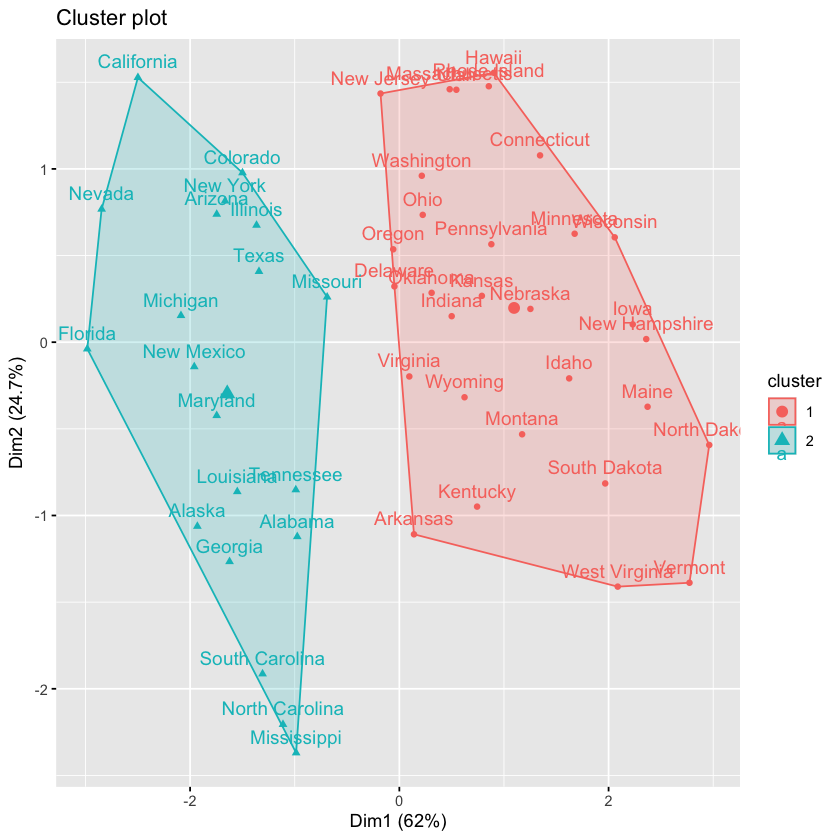

In [16]:
fviz_cluster(clus2, data = arrest.scal)

##### Elbow Plot

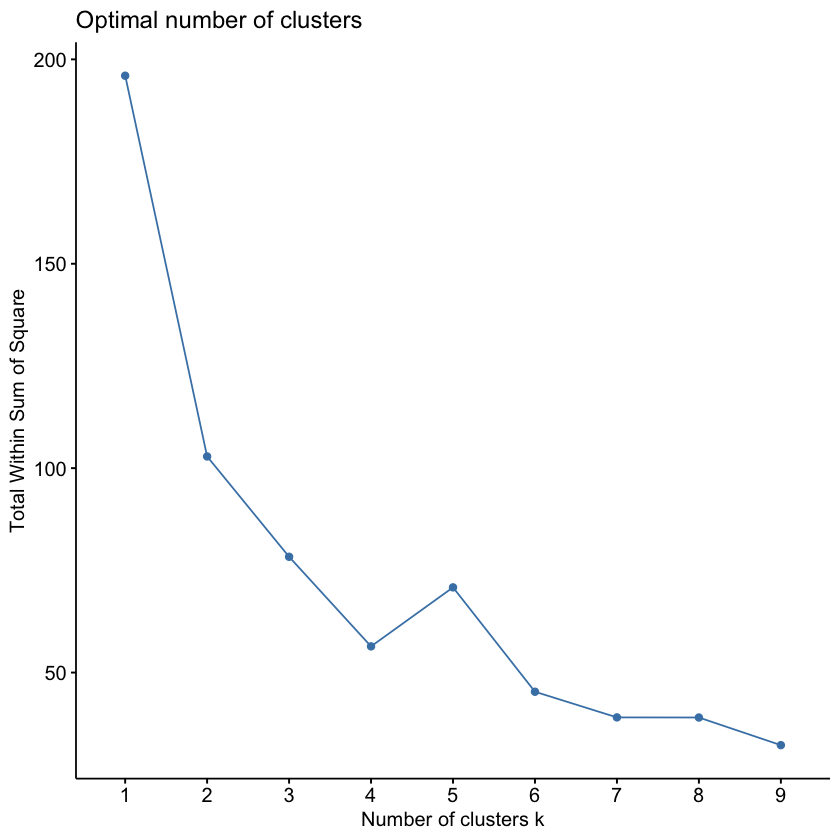

In [18]:
set.seed(12964)
fviz_nbclust(arrest.scal, kmeans, method = "wss",k.max = 9,)

##### Silhouette Stat
- closest to 1 is best

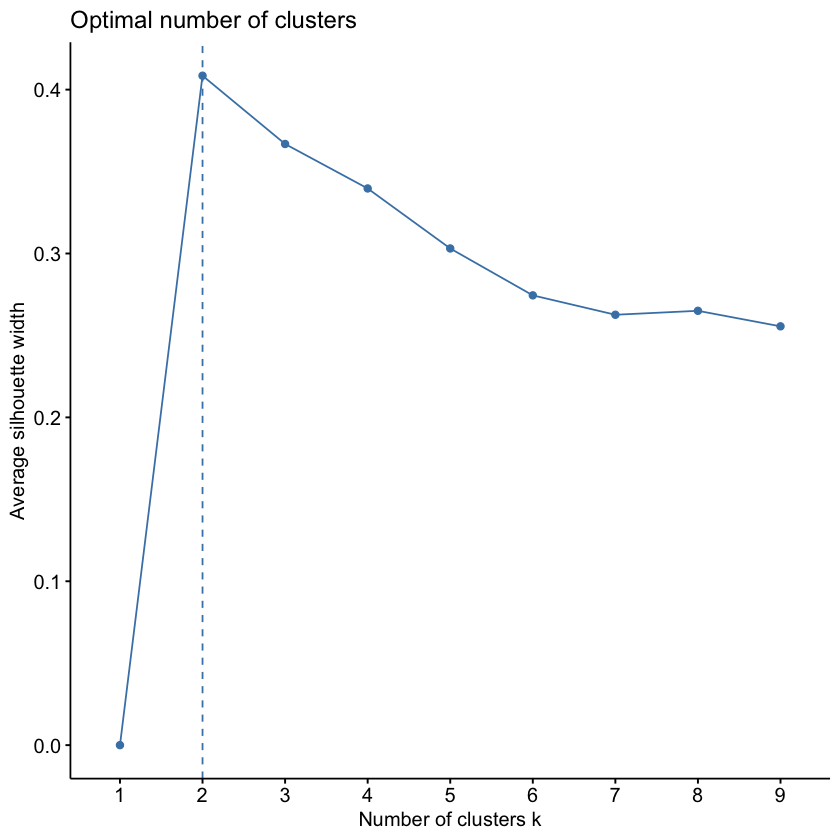

In [19]:
fviz_nbclust(arrest.scal, kmeans, method = "silhouette",k.max = 9)

##### Gap Statistic
- intracluster variation

In [21]:
install.packages("cluster")
library(cluster)


The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpJly9ML/downloaded_packages


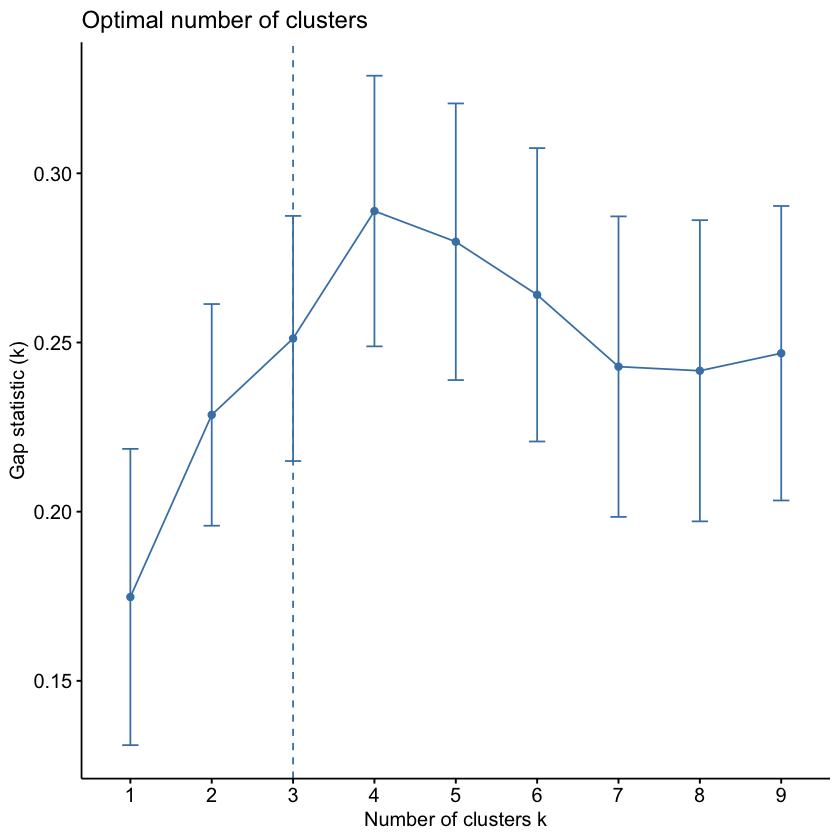

In [22]:
# set B, b is the number of Bootstrap samples
set.seed(123)
gap_stat = clusGap(arrest.scal, FUN = kmeans, nstart = 25, K.max = 9, B = 50)
fviz_gap_stat(gap_stat)

In [24]:
profile.kmeans=cbind(USArrests,k2$cluster)

all.k=profile.kmeans %>% group_by(k2$cluster) %>%
summarise(mean.assault=mean(Assault),mean.murder=mean(Murder),mean.rape=mean(Rape),mean.pop=mean(UrbanPop))


ERROR: Error in eval(expr, envir, enclos): object 'k2' not found


#### Hierarchical Clustering

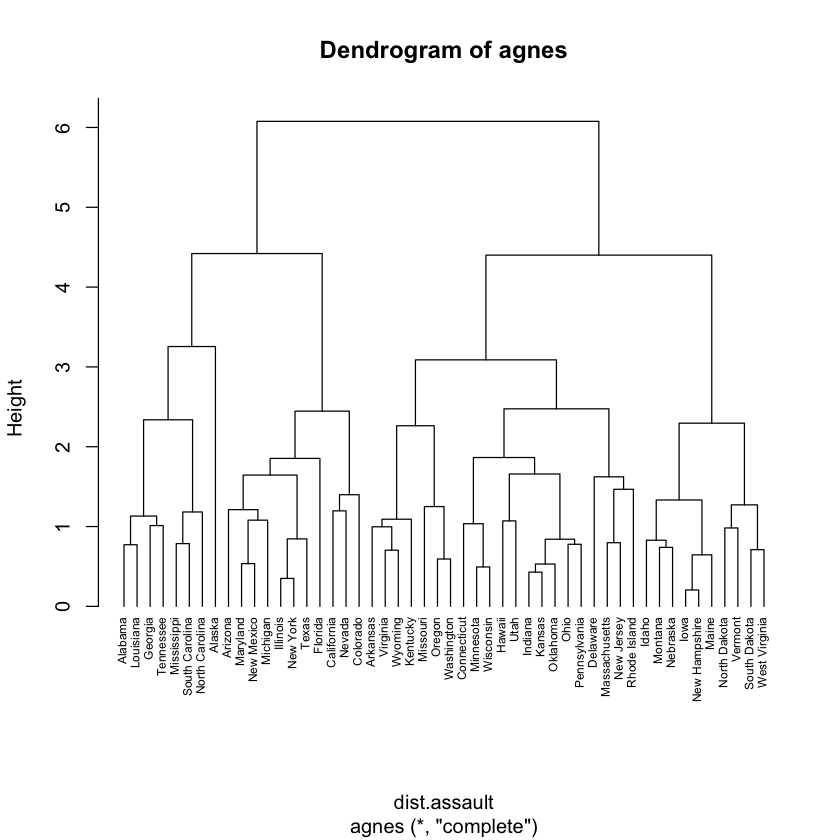

In [25]:
dist.assault=dist(arrest.scal,method = "euclidean")
h1.comp.eucl=agnes(dist.assault,method="complete")
pltree(h1.comp.eucl, cex = 0.6, hang = -1, main = "Dendrogram of agnes")

In [26]:
h1.comp.eucl$ac

[1] 0.8531583

##### Checking linkage metrics 

In [27]:
m <- c( "average", "single", "complete", "ward")
names(m) <- c( "average", "single", "complete", "ward")
# function to compute coefficient
ac <- function(x) {
agnes(dist.assault, method = x)$ac
}
map_dbl(m, ac)


average    single  complete      ward 
0.7379371 0.6276128 0.8531583 0.9346210

#### Creating Clusters

##### Agnes

In [ ]:
h2=agnes(dist.assault,method="ward")
h2_clus <- cutree(h2, k = 2)
H2_clus


##### NB Scan

In [32]:
install.packages("NbClust")


The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpJly9ML/downloaded_packages


In [33]:
library(NbClust)

*** : The Hubert index is a graphical method of determining the number of clusters.
                In the plot of Hubert index, we seek a significant knee that corresponds to a 
                significant increase of the value of the measure i.e the significant peak in Hubert
                index second differences plot. 
 


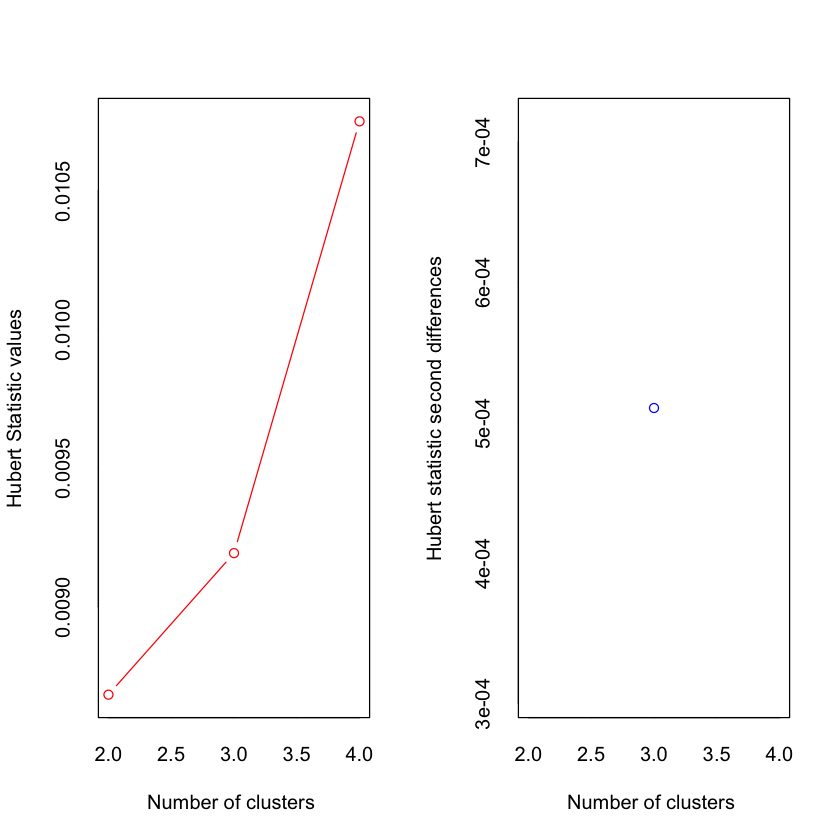

*** : The D index is a graphical method of determining the number of clusters. 
                In the plot of D index, we seek a significant knee (the significant peak in Dindex
                second differences plot) that corresponds to a significant increase of the value of
                the measure. 
 
******************************************************************* 
* Among all indices:                                                
* 9 proposed 2 as the best number of clusters 
* 9 proposed 3 as the best number of clusters 
* 5 proposed 4 as the best number of clusters 

                   ***** Conclusion *****                            
 
* According to the majority rule, the best number of clusters is  2 
 
 
******************************************************************* 


$All.index
        KL      CH Hartigan     CCC    Scott  Marriot   TrCovW   TraceW
2  26.3587 41.8949  11.5200 -0.3483  78.6988 725375.1 708.1600 104.6556
3   0.0704 31.0737  18.9426 -2.0049 107.4372 918599.5 331.2367  84.3997
4 393.5832 34.6264   5.4577 -0.7050 156.0842 617250.0 257.9307  60.1552
  Friedman  Rubin Cindex     DB Silhouette   Duda Pseudot2   Beale Ratkowsky
2   6.7099 1.8728 0.4031 1.0513     0.4048 0.5525  13.7698  1.8468    0.4404
3   8.1357 2.3223 0.3800 1.0433     0.3692 0.5918  20.0040  1.6098    0.4305
4  10.8610 3.2582 0.4334 1.0811     0.3160 1.0527  -0.3001 -0.1035    0.4155
     Ball Ptbiserial   Frey McClain   Dunn Hubert SDindex Dindex   SDbw
2 52.3278     0.6330 0.9663  0.5287 0.2637 0.0087  1.3745 1.3451 1.1226
3 28.1332     0.6315 0.8670  0.6873 0.2648 0.0092  1.2895 1.2025 0.7789
4 15.0388     0.5820 0.0448  1.3366 0.1622 0.0108  1.4085 1.0199 0.5029

$All.CriticalValues
  CritValue_Duda CritValue_PseudoT2 Fvalue_Beale
2         0.3773            28.0561       0.1300
3         0.4780            31.6758       0.1765
4         0.1265            41.4361       1.0000

$Best.nc
                      KL      CH Hartigan     CCC  Scott Marriot   TrCovW
Number_clusters   4.0000  2.0000   4.0000  2.0000  4.000       3   3.0000
Value_Index     393.5832 41.8949  13.4849 -0.3483 48.647 -494574 376.9233
                 TraceW Friedman  Rubin Cindex     DB Silhouette   Duda
Number_clusters  3.0000   4.0000 3.0000   3.00 3.0000     2.0000 2.0000
Value_Index     -3.9886   2.7253 0.4865   0.38 1.0433     0.4048 0.5525
                PseudoT2  Beale Ratkowsky    Ball PtBiserial Frey McClain
Number_clusters   2.0000 2.0000    2.0000  3.0000      2.000    1  2.0000
Value_Index      13.7698 1.8468    0.4404 24.1946      0.633   NA  0.5287
                  Dunn Hubert SDindex Dindex   SDbw
Number_clusters 3.0000      0  3.0000      0 4.0000
Value_Index     0.2648      0  1.2895      0 0.5029

$Best.partition
       Alabama         Alaska        Arizona       Arkansas     California 
             1              1              1              2              1 
      Colorado    Connecticut       Delaware        Florida        Georgia 
             1              2              2              1              1 
        Hawaii          Idaho       Illinois        Indiana           Iowa 
             2              2              1              2              2 
        Kansas       Kentucky      Louisiana          Maine       Maryland 
             2              2              1              2              1 
 Massachusetts       Michigan      Minnesota    Mississippi       Missouri 
             2              1              2              1              2 
       Montana       Nebraska         Nevada  New Hampshire     New Jersey 
             2              2              1              2              2 
    New Mexico       New York North Carolina   North Dakota           Ohio 
             1              1              1              2              2 
      Oklahoma         Oregon   Pennsylvania   Rhode Island South Carolina 
             2              2              2              2              1 
  South Dakota      Tennessee          Texas           Utah        Vermont 
             2              1              1              2              2 
      Virginia     Washington  West Virginia      Wisconsin        Wyoming 
             2              2              2              2              2

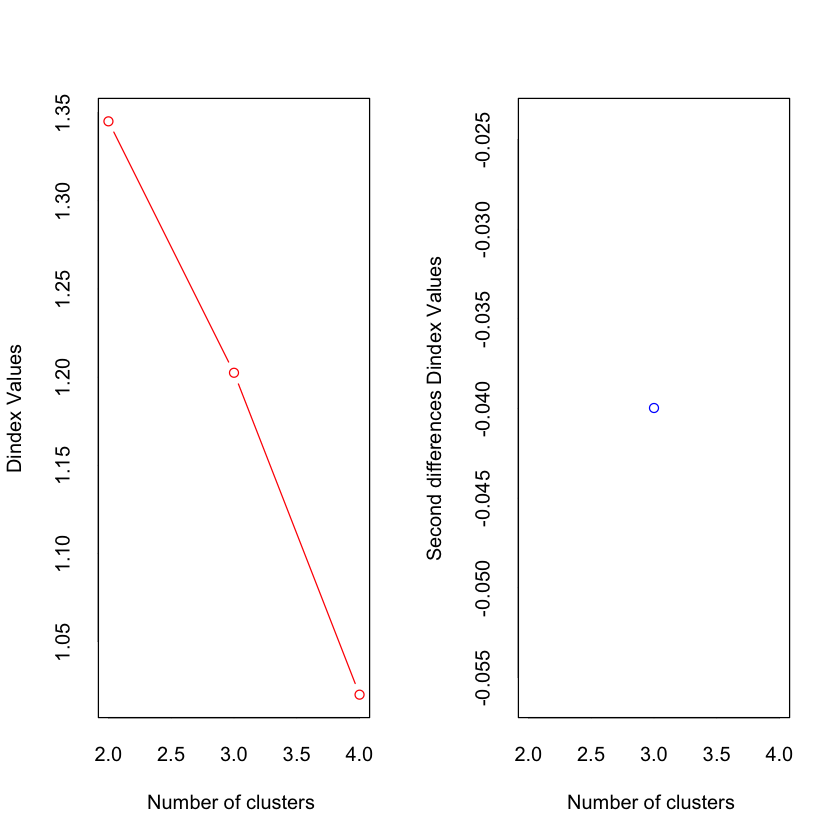

In [34]:
NbClust(arrest.scal,distance="euclidean",method="complete",min.nc=2,max.nc = 4)

#### Hierarchical DB Scan

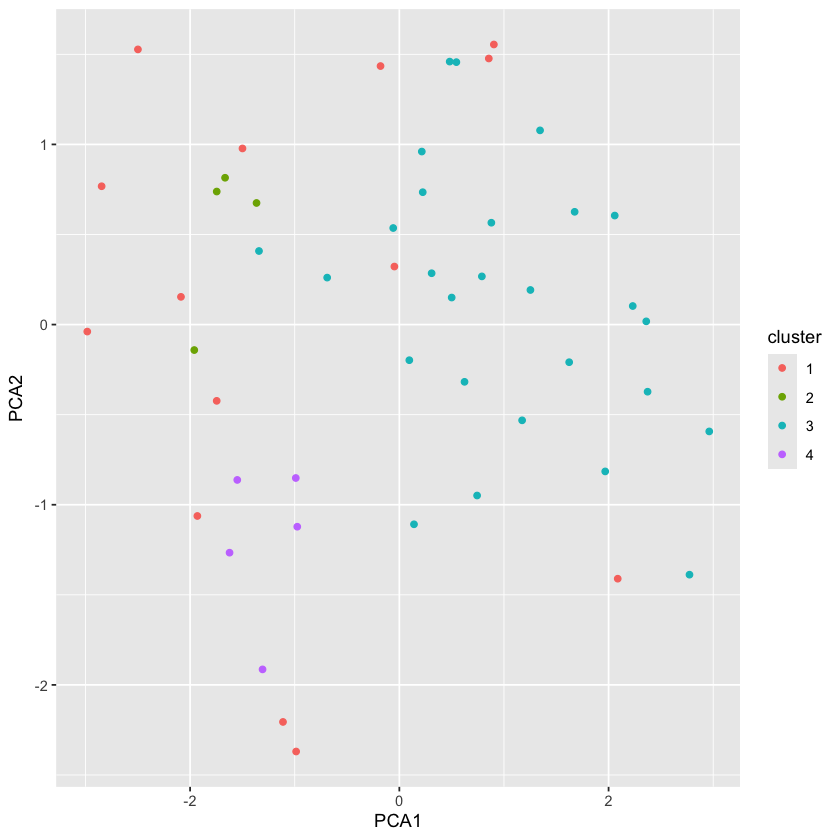

In [35]:
scan1<-hdbscan(arrest.scal,minPts=4)
pca_ex=prcomp(arrest.scal,scale=F)
scan1data=cbind.data.frame(pca_ex$x[,1],pca_ex$x[
,2],as.factor(scan1$cluster+1))
colnames(scan1data)=c("PCA1","PCA2","cluster")
ggplot(scan1data,aes(x=PCA1,y=PCA2,color=cluster
))+geom_point()+ scale_fill_brewer(palette = 
"Dark2")

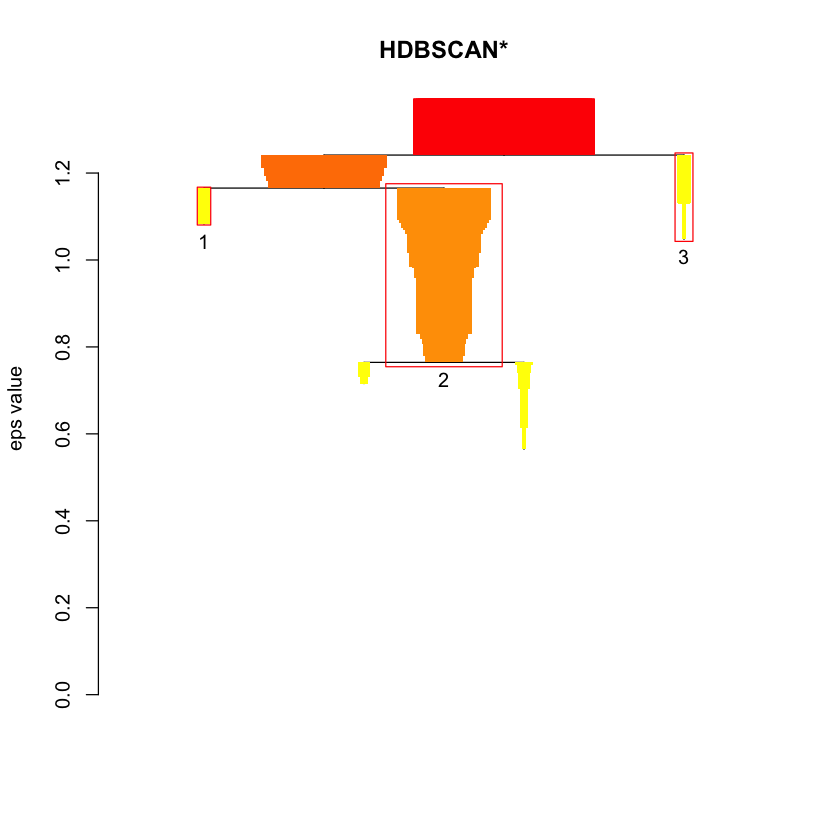

In [36]:
plot(scan1,show_flat=T)


#### Variable Clustering

In [39]:
telco=read.csv("https://raw.githubusercontent.com/sjsimmo2/DataMining-Fall/refs/heads/master/TelcoChurn.csv",header=T)
telco[is.na(telco)] = 0
quant.var=telco[,c(3,6,19,20)]
qual.var=telco[,c(2,4,5,7:18)]

var.clust.h=hclustvar(quant.var, qual.var)
stab=stability(var.clust.h,B=50) ## This will take time!

ERROR: Error in hclustvar(quant.var, qual.var): could not find function "hclustvar"
